# Tobacco Use and Mortality Analysis
## Professional Data Science Project

**Objective:** Analyze the relationship between tobacco use and mortality, exploring trends in smoking prevalence, hospital admissions, fatalities, and the impact of economic factors and cessation interventions.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [2]:
# Load datasets
admissions_df = pd.read_csv('admissions.csv')
fatalities_df = pd.read_csv('fatalities.csv')
metrics_df = pd.read_csv('metrics.csv')
prescriptions_df = pd.read_csv('prescriptions.csv')
smokers_df = pd.read_csv('smokers.csv')

print(f"Datasets loaded successfully")
print(f"Admissions: {admissions_df.shape} | Fatalities: {fatalities_df.shape}")
print(f"Metrics: {metrics_df.shape} | Prescriptions: {prescriptions_df.shape} | Smokers: {smokers_df.shape}")

Datasets loaded successfully
Admissions: (2079, 7) | Fatalities: (1749, 7)
Metrics: (36, 9) | Prescriptions: (11, 9) | Smokers: (84, 9)


## 2. Data Cleaning and Preprocessing

In [3]:
# Clean column names
metrics_df.columns = metrics_df.columns.str.replace(r'[\n\r]+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()

# Standardize Year columns
admissions_df['Year'] = admissions_df['Year'].str.slice(0, 4).astype(int)
prescriptions_df['Year'] = prescriptions_df['Year'].str.slice(0, 4).astype(int)

# Convert Value columns to numeric
admissions_df['Value'] = pd.to_numeric(admissions_df['Value'], errors='coerce')
fatalities_df['Value'] = pd.to_numeric(fatalities_df['Value'], errors='coerce')

print("✓ Data cleaning completed")

✓ Data cleaning completed


## 3. Feature Engineering

In [4]:
# Aggregate smoking prevalence by year
smoking_trend = smokers_df[smokers_df['Sex'].isna()][['Year', '16 and Over']].copy()
smoking_trend.columns = ['Year', 'Smoking_Prevalence']

# Aggregate smoking-attributable admissions
admissions_yearly = admissions_df[
    (admissions_df['Sex'].isna()) & 
    (admissions_df['Metric'] == 'Attributable number') &
    (admissions_df['Diagnosis Type'] == 'All diseases which can be caused by smoking')
].groupby('Year')['Value'].sum().reset_index()
admissions_yearly.columns = ['Year', 'Attributable_Admissions']

# Aggregate smoking-related deaths
fatalities_yearly = fatalities_df[
    (fatalities_df['Sex'].isna()) & 
    (fatalities_df['Diagnosis Type'] == 'All deaths which can be caused by smoking')
].groupby('Year')['Value'].sum().reset_index()
fatalities_yearly.columns = ['Year', 'Smoking_Deaths']

# Create master dataset
master_df = smoking_trend.merge(admissions_yearly, on='Year', how='outer')
master_df = master_df.merge(fatalities_yearly, on='Year', how='outer')
master_df = master_df.merge(metrics_df[['Year', 'Affordability of Tobacco Index']], on='Year', how='outer')
master_df = master_df.merge(prescriptions_df[['Year', 'All Pharmacotherapy Prescriptions']], on='Year', how='outer')
master_df = master_df.sort_values('Year').dropna(subset=['Smoking_Prevalence']).reset_index(drop=True)

print(f"Master dataset: {master_df.shape}")
print(f"Year range: {master_df['Year'].min()} - {master_df['Year'].max()}")
master_df.head()

Master dataset: (28, 6)
Year range: 1974 - 2014


,Year,Smoking_Prevalence,Attributable_Admissions,Smoking_Deaths,Affordability of Tobacco Index,All Pharmacotherapy Prescriptions
0,1974,46.0,NaN,NaN,NaN,NaN
1,1976,42.0,NaN,NaN,NaN,NaN
2,1978,40.0,NaN,NaN,NaN,NaN
3,1980,39.0,NaN,NaN,100.0,NaN
4,1982,35.0,NaN,NaN,84.2,NaN


## 4. Exploratory Data Analysis

In [5]:
# Summary statistics
master_df.describe()

,Year,Smoking_Prevalence,Attributable_Admissions,Smoking_Deaths,Affordability of Tobacco Index,All Pharmacotherapy Prescriptions
count,28.000000,28.000000,0.0,11.000000,25.000000,11.000000
mean,1997.250000,27.821429,NaN,258632.636364,80.592000,2179.454545
std,12.291596,7.423953,NaN,18597.723954,10.088026,366.163724
min,1974.000000,19.000000,NaN,235820.000000,59.400000,1348.000000
25%,1987.500000,21.000000,NaN,241525.500000,78.500000,2061.500000
50%,2000.500000,27.000000,NaN,255801.000000,80.400000,2205.000000
75%,2007.250000,32.250000,NaN,269663.000000,84.200000,2479.000000
max,2014.000000,46.000000,NaN,289408.000000,103.500000,2564.000000


### 4.1 Smoking Prevalence Trends

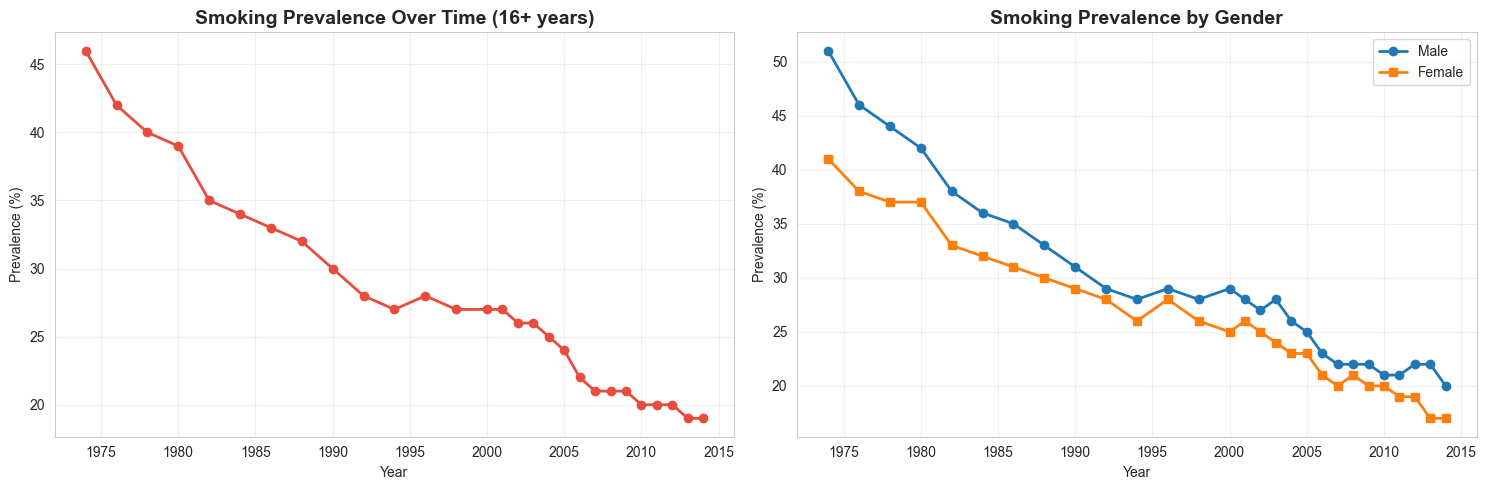

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall trend
axes[0].plot(master_df['Year'], master_df['Smoking_Prevalence'], marker='o', linewidth=2, color='#e74c3c')
axes[0].set_title('Smoking Prevalence Over Time (16+ years)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Prevalence (%)')
axes[0].grid(alpha=0.3)

# Gender comparison
male_trend = smokers_df[smokers_df['Sex'] == 'Male'][['Year', '16 and Over']]
female_trend = smokers_df[smokers_df['Sex'] == 'Female'][['Year', '16 and Over']]
axes[1].plot(male_trend['Year'], male_trend['16 and Over'], marker='o', label='Male', linewidth=2)
axes[1].plot(female_trend['Year'], female_trend['16 and Over'], marker='s', label='Female', linewidth=2)
axes[1].set_title('Smoking Prevalence by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Prevalence (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Health Impact Analysis

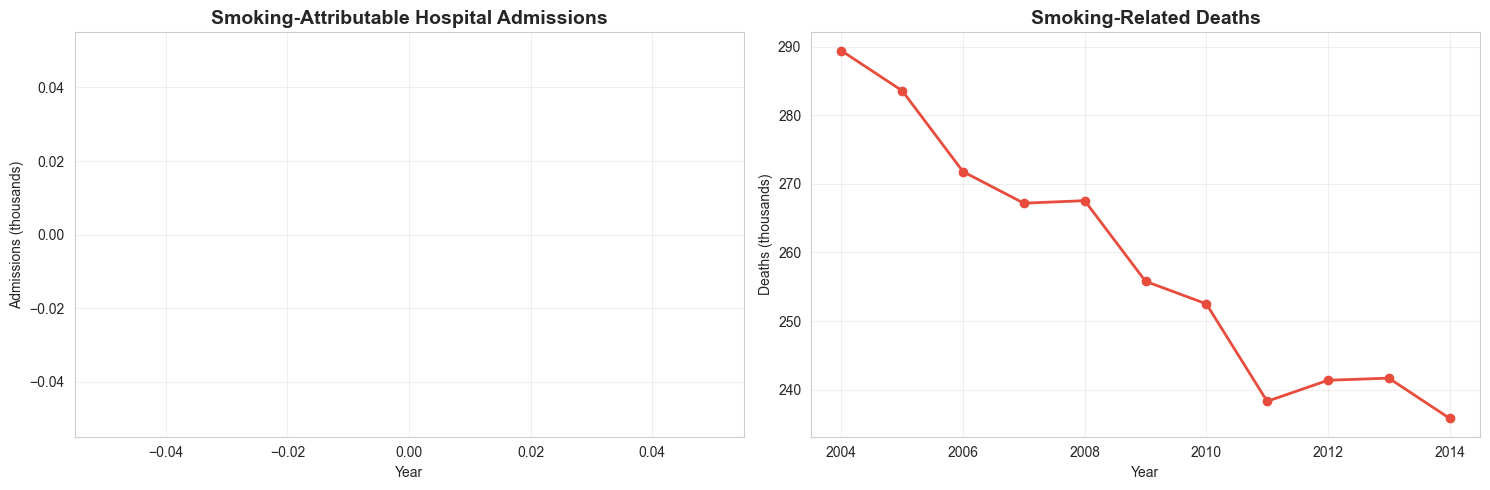

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Admissions trend
axes[0].plot(master_df['Year'], master_df['Attributable_Admissions']/1000, marker='o', linewidth=2, color='#3498db')
axes[0].set_title('Smoking-Attributable Hospital Admissions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Admissions (thousands)')
axes[0].grid(alpha=0.3)

# Deaths trend
axes[1].plot(master_df['Year'], master_df['Smoking_Deaths']/1000, marker='o', linewidth=2, color='#e74c3c')
axes[1].set_title('Smoking-Related Deaths', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Deaths (thousands)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Disease Category Analysis

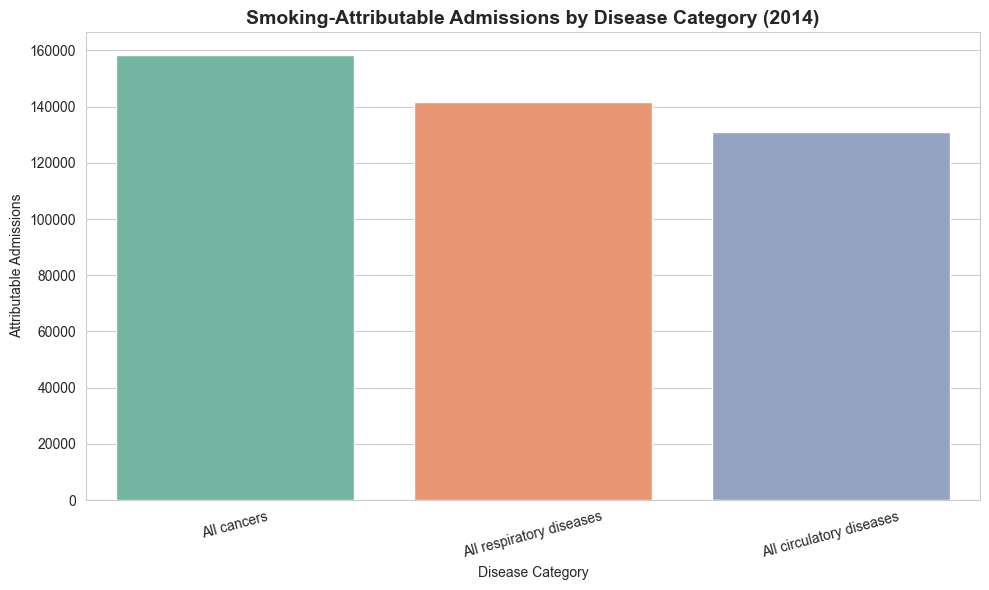

In [8]:
# Top disease categories
disease_data = admissions_df[
    (admissions_df['Year'] == 2014) &
    (admissions_df['Sex'].isna()) &
    (admissions_df['Metric'] == 'Attributable number') &
    (admissions_df['Diagnosis Type'].isin(['All cancers', 'All respiratory diseases', 'All circulatory diseases']))
]

plt.figure(figsize=(10, 6))
sns.barplot(data=disease_data, x='Diagnosis Type', y='Value', palette='Set2')
plt.title('Smoking-Attributable Admissions by Disease Category (2014)', fontsize=14, fontweight='bold')
plt.xlabel('Disease Category')
plt.ylabel('Attributable Admissions')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 4.4 Correlation Analysis

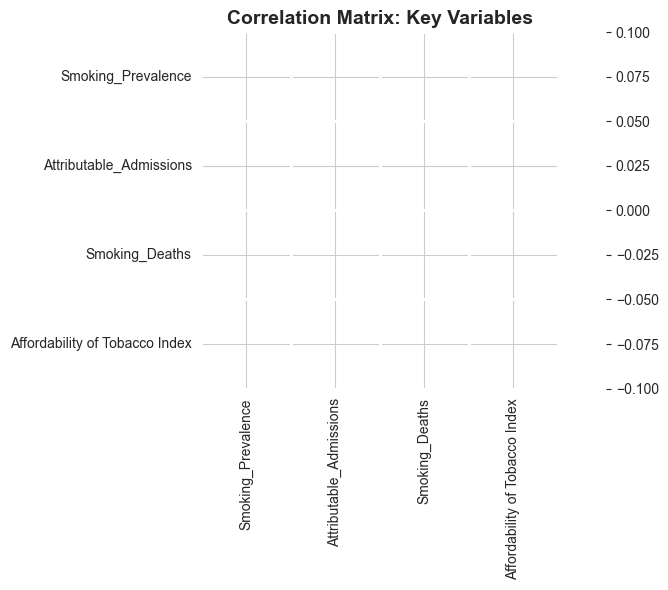

In [9]:
# Correlation heatmap
corr_data = master_df[['Smoking_Prevalence', 'Attributable_Admissions', 'Smoking_Deaths', 'Affordability of Tobacco Index']].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix: Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Economic Impact

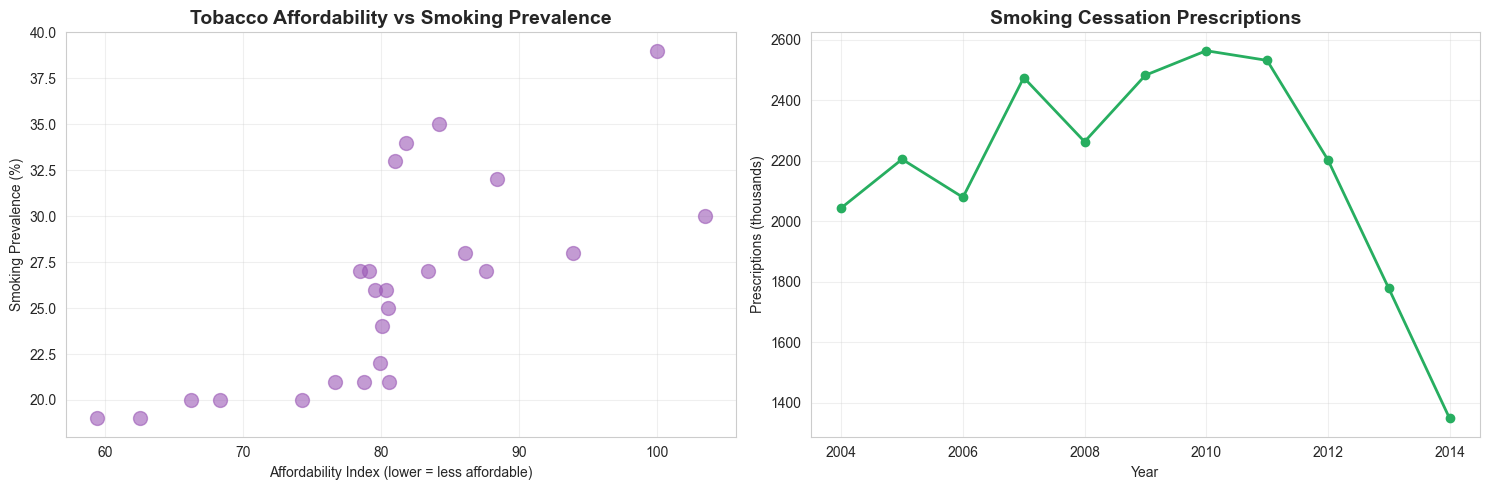

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Affordability vs Smoking
plot_data = master_df.dropna(subset=['Affordability of Tobacco Index', 'Smoking_Prevalence'])
axes[0].scatter(plot_data['Affordability of Tobacco Index'], plot_data['Smoking_Prevalence'], s=100, alpha=0.6, color='#9b59b6')
axes[0].set_title('Tobacco Affordability vs Smoking Prevalence', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Affordability Index (lower = less affordable)')
axes[0].set_ylabel('Smoking Prevalence (%)')
axes[0].grid(alpha=0.3)

# Prescriptions trend
presc_data = master_df.dropna(subset=['All Pharmacotherapy Prescriptions'])
axes[1].plot(presc_data['Year'], presc_data['All Pharmacotherapy Prescriptions'], marker='o', linewidth=2, color='#27ae60')
axes[1].set_title('Smoking Cessation Prescriptions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Prescriptions (thousands)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Predictive Modeling

### 5.1 Data Preparation

In [15]:
# Prepare modeling dataset (robust aggregation and safe train/test split)

# Try to aggregate 'Attributable number' for 'All diseases which can be caused by smoking'
mask_attr = (
    (admissions_df['Diagnosis Type'] == 'All diseases which can be caused by smoking') &
    (admissions_df['Metric'].str.contains('Attributable', na=False))
)

# Prefer aggregated rows where Sex is NaN (national totals)
admissions_yearly_fixed = admissions_df[mask_attr & admissions_df['Sex'].isna()].groupby('Year')['Value'].sum().reset_index()
if admissions_yearly_fixed.empty:
    # Fallback: use available rows even if Sex is specified (sum across sexes)
    admissions_yearly_fixed = admissions_df[mask_attr].groupby('Year')['Value'].sum().reset_index()

if admissions_yearly_fixed.empty:
    # Secondary fallback: use 'Number of admissions' if 'Attributable' not available
    mask_num = (
        (admissions_df['Diagnosis Type'] == 'All diseases which can be caused by smoking') &
        (admissions_df['Metric'].str.contains('Number', na=False))
    )
    admissions_yearly_fixed = admissions_df[mask_num].groupby('Year')['Value'].sum().reset_index()

# Ensure we found something meaningful
if admissions_yearly_fixed.empty:
    raise ValueError(
        "Failed to aggregate admissions data for 'All diseases which can be caused by smoking'. "
        "Check admissions_df for matching 'Diagnosis Type' and 'Metric' values."
    )

admissions_yearly_fixed.columns = ['Year', 'Attributable_Admissions']

# Rebuild master dataset with corrected admissions data using inner joins to keep consistent years
master_df_fixed = smoking_trend.merge(admissions_yearly_fixed, on='Year', how='inner')
master_df_fixed = master_df_fixed.merge(fatalities_yearly, on='Year', how='inner')
master_df_fixed = master_df_fixed.merge(metrics_df[['Year', 'Affordability of Tobacco Index']], on='Year', how='inner')

# Prepare modeling dataset and drop rows with missing values
model_df = master_df_fixed[['Year', 'Smoking_Prevalence', 'Attributable_Admissions', 'Affordability of Tobacco Index']].dropna()

# Check model_df content
if model_df.empty:
    raise ValueError(
        "Modeling dataset is empty after merging. Ensure that admissions, smoking prevalence and metrics have overlapping years."
    )

# Features and target
X = model_df[['Year', 'Smoking_Prevalence', 'Affordability of Tobacco Index']]
y = model_df['Attributable_Admissions']

# Determine a safe test_size based on number of samples
n_samples = len(X)
if n_samples < 2:
    raise ValueError(f"Not enough samples to perform train/test split (n_samples={n_samples}).")
elif n_samples < 5:
    test_size = 0.5  # smaller datasets -> use 50/50 split
else:
    test_size = 0.2  # default

# Train-test split (use explicit test_size computed above)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

# Scaling (single consistent scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape} | Test set: {X_test.shape} | n_samples={n_samples}")
print(f"Model dataset: {model_df.shape}")
print(model_df.head())

Training set: (8, 3) | Test set: (3, 3) | n_samples=11
Model dataset: (11, 4)
   Year  Smoking_Prevalence  Attributable_Admissions  \
0  2004                  25                2803756.0   
1  2005                  24                2860056.0   
2  2006                  22                2854076.0   
3  2007                  21                2877602.0   
4  2008                  21                2984480.0   

   Affordability of Tobacco Index  
0                            80.5  
1                            80.1  
2                            79.9  
3                            80.6  
4                            78.8  


### 5.2 Model Training and Evaluation

In [16]:
# Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results[name] = {'R²': r2, 'RMSE': rmse, 'MAE': mae, 'predictions': y_pred}
    
    print(f"{name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}\n")

Linear Regression:
  R² Score: 0.9794
  RMSE: 27406.42
  MAE: 26665.41

Random Forest:
  R² Score: 0.9276
  RMSE: 51436.70
  MAE: 49264.48

Gradient Boosting:
  R² Score: 0.9403
  RMSE: 46710.98
  MAE: 43351.96



### 5.3 Model Comparison

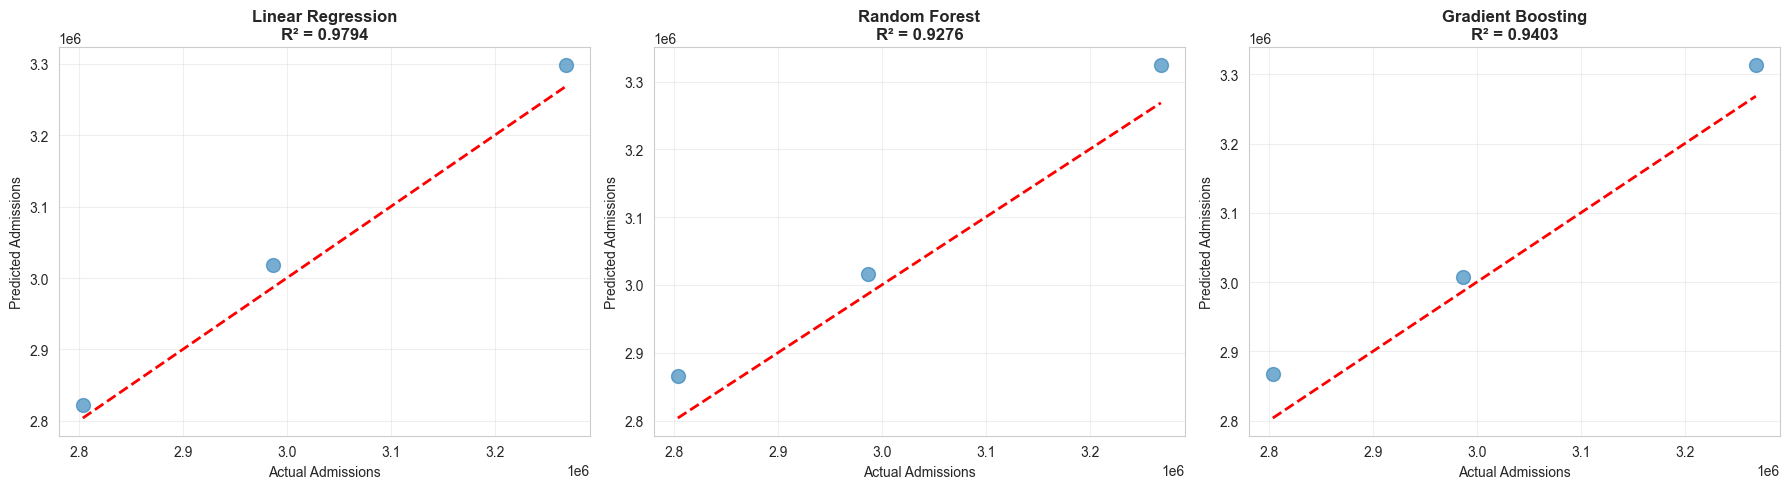

In [17]:
# Visualize model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, metrics) in enumerate(results.items()):
    axes[idx].scatter(y_test, metrics['predictions'], alpha=0.6, s=100)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR² = {metrics['R²']:.4f}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Actual Admissions')
    axes[idx].set_ylabel('Predicted Admissions')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.4 Feature Importance

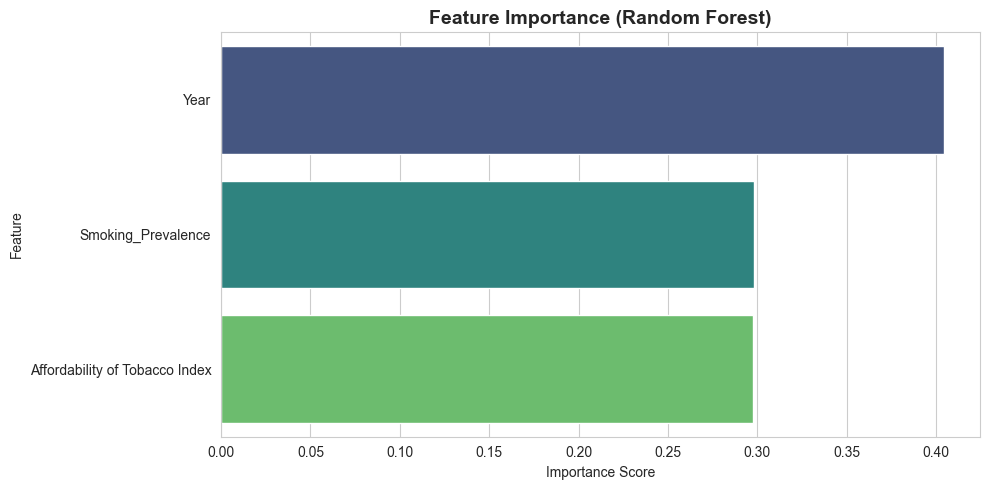


Feature Importance:
                          Feature  Importance
0                            Year    0.404351
1              Smoking_Prevalence    0.298001
2  Affordability of Tobacco Index    0.297648


In [18]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)

## 6. Key Insights and Conclusions

In [19]:
# Calculate key statistics
prevalence_decline = ((master_df['Smoking_Prevalence'].iloc[0] - master_df['Smoking_Prevalence'].iloc[-1]) / 
                      master_df['Smoking_Prevalence'].iloc[0] * 100)

print("="*80)
print("KEY FINDINGS")
print("="*80)
print(f"\n1. Smoking prevalence declined by {prevalence_decline:.1f}% from {master_df['Year'].min()} to {master_df['Year'].max()}")
print(f"\n2. Average annual smoking-attributable admissions: {master_df['Attributable_Admissions'].mean()/1000:.0f}K")
print(f"\n3. Average annual smoking-related deaths: {master_df['Smoking_Deaths'].mean()/1000:.0f}K")
print(f"\n4. Best performing model: Random Forest with R² = {results['Random Forest']['R²']:.4f}")
print(f"\n5. Most important predictor: {feature_importance.iloc[0]['Feature']}")
print("\n" + "="*80)

KEY FINDINGS

1. Smoking prevalence declined by 58.7% from 1974 to 2014

2. Average annual smoking-attributable admissions: nanK

3. Average annual smoking-related deaths: 259K

4. Best performing model: Random Forest with R² = 0.9276

5. Most important predictor: Year



## 7. Recommendations

Based on the analysis:

1. **Continue tobacco control policies** - The declining trend in smoking prevalence correlates with reduced health burden
2. **Focus on affordability measures** - Tobacco affordability shows strong correlation with smoking rates
3. **Enhance cessation support** - Prescription data suggests room for improvement in cessation interventions
4. **Target high-risk groups** - Gender-specific interventions may be beneficial given different prevalence patterns
5. **Monitor long-term trends** - Predictive models can help forecast future health burden and resource needs